In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ipc_crimes_final.csv")
df = df.drop(columns=['Unnamed: 10', 'Unnamed: 11'])
numeric_cols = [
    'current_month_reg',
    'current_month_det',
    'previous_month_reg',
    'previous_month_det',
    'current_year_reg',
    'current_year_det',
    'previous_year_reg',
    'previous_year_det'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.head()

,month,crime_category,current_month_reg,current_month_det,previous_month_reg,previous_month_det,current_year_reg,current_year_det,previous_year_reg,previous_year_det
0,2026-03,Murder,20.0,19.0,10.0,10.0,39.0,38.0,34.0,34.0
1,2026-03,Att.to.C.Murder,46.0,44.0,30.0,27.0,100.0,98.0,69.0,68.0
2,2026-03,Dacoity,1.0,1.0,2.0,2.0,6.0,6.0,2.0,2.0
3,2026-03,Prep.for Dacoity,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
4,2026-03,Robbery,38.0,37.0,27.0,24.0,90.0,88.0,74.0,74.0


In [13]:
print(df.shape)

df.info()

df.describe()

(1782, 10)
<class 'pandas.DataFrame'>
RangeIndex: 1782 entries, 0 to 1781
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   month               1782 non-null   str    
 1   crime_category      1782 non-null   str    
 2   current_month_reg   1493 non-null   float64
 3   current_month_det   1533 non-null   float64
 4   previous_month_reg  1493 non-null   float64
 5   previous_month_det  1533 non-null   float64
 6   current_year_reg    1273 non-null   float64
 7   current_year_det    1357 non-null   float64
 8   previous_year_reg   1269 non-null   float64
 9   previous_year_det   1369 non-null   float64
dtypes: float64(8), str(2)
memory usage: 139.3 KB


,current_month_reg,current_month_det,previous_month_reg,previous_month_det,current_year_reg,current_year_det,previous_year_reg,previous_year_det
count,1493.000000,1533.000000,1493.000000,1533.000000,1273.000000,1357.000000,1269.000000,1369.000000
mean,157.922974,107.181344,157.898192,106.564253,714.988217,540.853058,645.877857,473.986852
std,440.871179,347.342018,434.818783,340.366451,3050.153253,2433.204836,2392.120210,1757.997631
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,9.000000,14.000000,9.000000,48.000000,40.000000,44.000000,37.000000
50%,41.000000,26.000000,41.000000,25.000000,161.000000,134.000000,158.000000,134.000000
75%,176.000000,68.000000,177.000000,68.000000,448.000000,367.000000,466.000000,382.000000
max,5911.000000,4980.000000,5129.000000,4198.000000,42884.000000,37377.000000,31066.000000,24864.000000


In [14]:
df.isnull().sum().sort_values(ascending=False)


previous_year_reg     513
current_year_reg      509
current_year_det      425
previous_year_det     413
previous_month_reg    289
current_month_reg     289
previous_month_det    249
current_month_det     249
crime_category          0
month                   0
dtype: int64

In [15]:
(df.isnull().sum()/len(df)*100).sort_values(ascending=False)

previous_year_reg     28.787879
current_year_reg      28.563412
current_year_det      23.849607
previous_year_det     23.176207
previous_month_reg    16.217733
current_month_reg     16.217733
previous_month_det    13.973064
current_month_det     13.973064
crime_category         0.000000
month                  0.000000
dtype: float64

In [16]:
df["crime_category"].nunique()

18

In [17]:
crime_totals = (
    df.groupby("crime_category")["current_month_reg"]
      .sum()
      .sort_values(ascending=False)
)

print(crime_totals.head(20))

crime_category
Other I.P.C.               72072.0
Thefts.                    48413.0
Hurt                       36443.0
M.V.Thefts.                19604.0
Molestation                19278.0
Rape                        7158.0
H.B.T.Night.                7154.5
H.B.T.Day                   5984.5
Robbery                     5649.0
Snatching                   3857.0
Riots.                      3028.0
Att.to.C.Murder             2547.0
Extortion                   2096.0
Robbery Chain Snatching     1142.0
Murder                      1118.0
Dacoity                      151.0
Att.to.C.Robbery              52.0
Prep.for Dacoity              32.0
Name: current_month_reg, dtype: float64


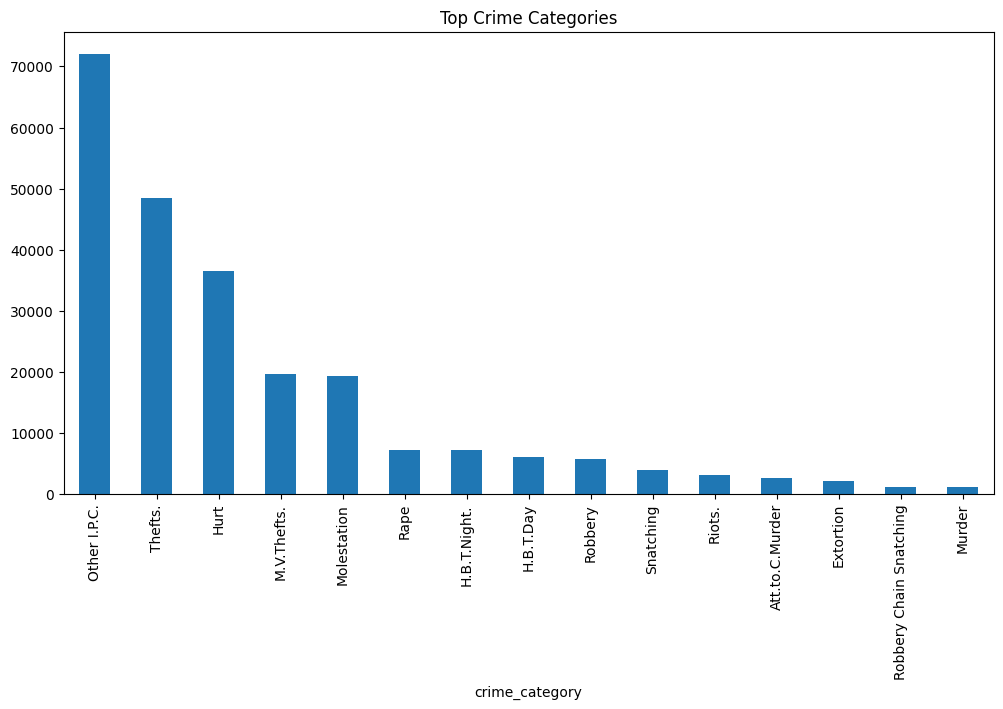

In [18]:
plt.figure(figsize=(12,6))
crime_totals.head(15).plot(kind="bar")
plt.title("Top Crime Categories")
plt.show()

In [20]:
detection = (
    df.groupby("crime_category")
      .agg({
          "current_month_reg": "sum",
          "current_month_det": "sum"
      })
)

detection["detection_ratio"] = (
    detection["current_month_det"]
    / detection["current_month_reg"]
    * 100
)

detection = detection.sort_values(
    "detection_ratio",
    ascending=False
)

print(detection)

                         current_month_reg  current_month_det  detection_ratio
crime_category                                                                
Other I.P.C.                       72072.0            81868.0       113.591964
Prep.for Dacoity                      32.0               32.0       100.000000
Murder                              1118.0             1036.0        92.665474
Att.to.C.Murder                     2547.0             2350.0        92.265410
Dacoity                              151.0              133.0        88.079470
Att.to.C.Robbery                      52.0               45.0        86.538462
Robbery                             5649.0             4497.0        79.607010
Hurt                               36443.0            28214.0        77.419532
Riots.                              3028.0             2260.0        74.636724
Rape                                7158.0             5322.0        74.350377
Molestation                        19278.0          

In [21]:
df[df["crime_category"]=="Murder"][
    ["month","current_year_reg"]
].tail(15)

,month,current_year_reg
1512,2019-03,34.0
1530,2019-02,20.0
1548,2019-01,10.0
1566,2018-12,164.0
1584,2018-11,152.0
1602,2018-10,140.0
1620,2018-09,125.0
1638,2018-08,108.0
1656,2018-07,98.0
1674,2018-06,85.0


                         detection_efficiency  backlog_change backlog_status
crime_category                                                              
Thefts.                                 49.80         11418.0     Increasing
Other I.P.C.                            88.76          9940.0     Increasing
H.B.T.Night.                            57.88          3257.5     Increasing
M.V.Thefts.                             78.23          2129.0     Increasing
H.B.T.Day                               62.44          1968.5     Increasing
Robbery                                 91.16           500.0     Increasing
Rape                                    93.94           480.0     Increasing
Extortion                               83.37           352.0     Increasing
Riots.                                  90.52           291.0     Increasing
Robbery Chain Snatching                 82.82           197.0     Increasing
Snatching                               89.79           118.0     Increasing

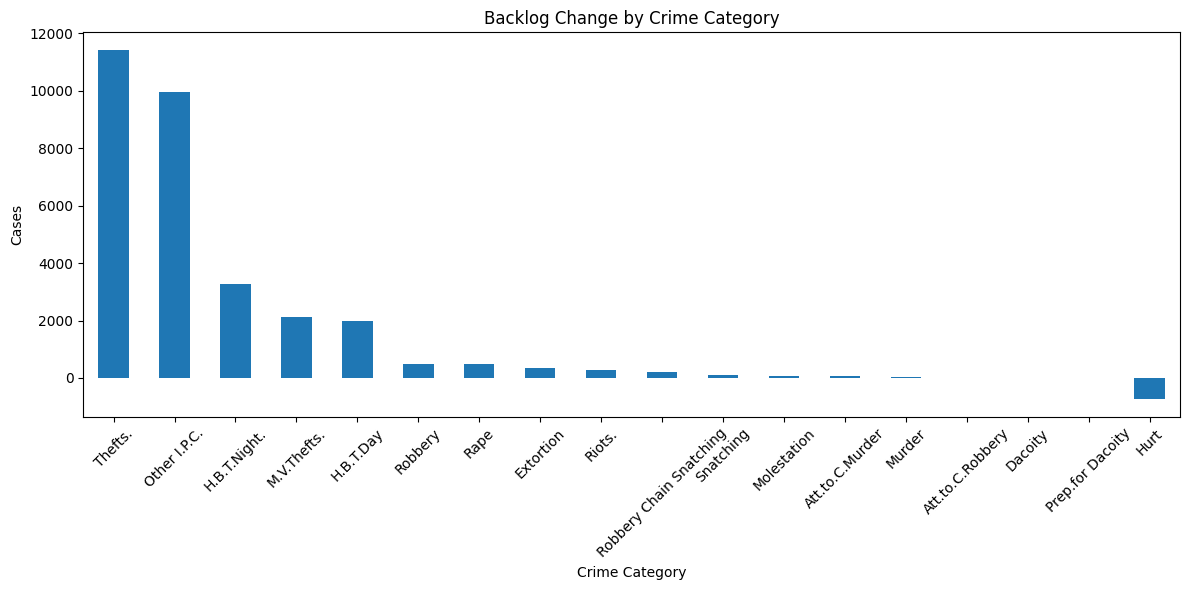

In [24]:
df["year"] = pd.to_datetime(df["month"]).dt.year

yearly = (
    df.sort_values("month")
      .groupby(["year", "crime_category"])
      .last()
)

metrics = (
    yearly.groupby("crime_category")
          .agg({
              "current_year_reg": "sum",
              "current_year_det": "sum"
          })
)

metrics["detection_efficiency"] = (
    metrics["current_year_det"]
    / metrics["current_year_reg"]
    * 100
).round(2)

metrics["backlog_change"] = (
    metrics["current_year_reg"]
    - metrics["current_year_det"]
)

metrics["backlog_status"] = metrics["backlog_change"].apply(
    lambda x: "Reducing" if x < 0 else "Increasing"
)

metrics = metrics.sort_values(
    "backlog_change",
    ascending=False
)

print(
    metrics[
        [
            "detection_efficiency",
            "backlog_change",
            "backlog_status"
        ]
    ]
)

plt.figure(figsize=(12, 6))

metrics["backlog_change"].plot(
    kind="bar"
)

plt.title("Backlog Change by Crime Category")
plt.ylabel("Cases")
plt.xlabel("Crime Category")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

                         detection_efficiency  backlog_change backlog_status
crime_category                                                              
Thefts.                                 49.80         11418.0     Increasing
H.B.T.Night.                            57.88          3257.5     Increasing
H.B.T.Day                               62.44          1968.5     Increasing
M.V.Thefts.                             78.23          2129.0     Increasing
Robbery Chain Snatching                 82.82           197.0     Increasing


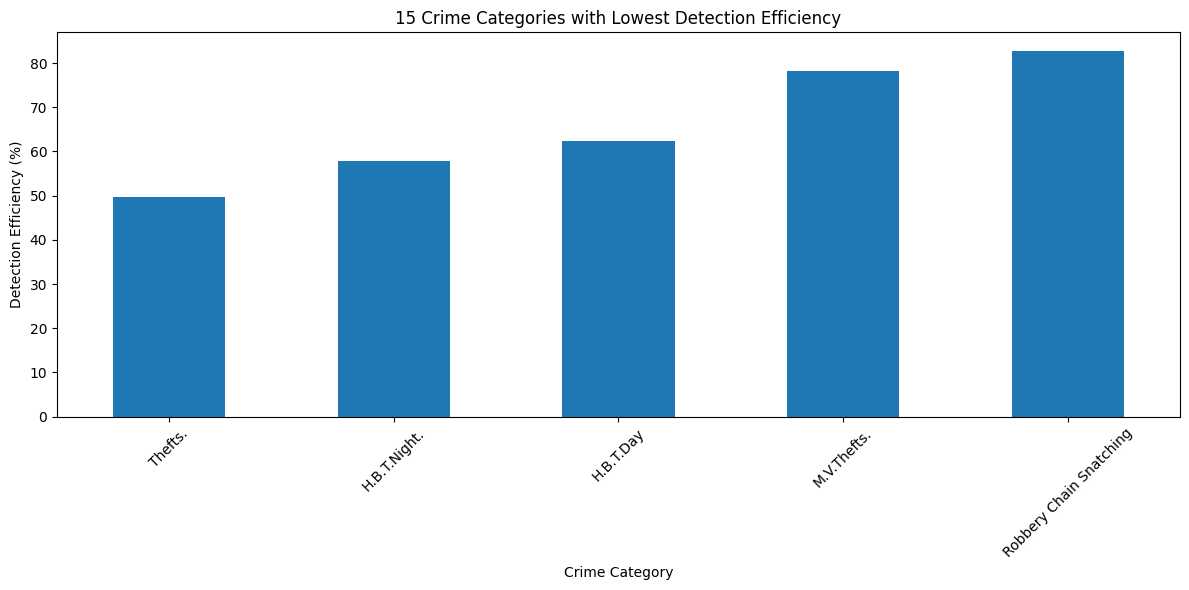

In [26]:
worst = metrics.sort_values(
    "detection_efficiency"
).head(5)

print(
    worst[
        [
            "detection_efficiency",
            "backlog_change",
            "backlog_status"
        ]
    ]
)

plt.figure(figsize=(12,6))

worst["detection_efficiency"].plot(
    kind="bar"
)

plt.title("15 Crime Categories with Lowest Detection Efficiency")
plt.ylabel("Detection Efficiency (%)")
plt.xlabel("Crime Category")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

                  detection_efficiency  backlog_change backlog_status
crime_category                                                       
Hurt                            105.26          -734.0       Reducing
Prep.for Dacoity                100.00             0.0     Increasing
Molestation                      99.36            69.0     Increasing
Dacoity                          98.25             3.0     Increasing
Att.to.C.Murder                  97.87            55.0     Increasing


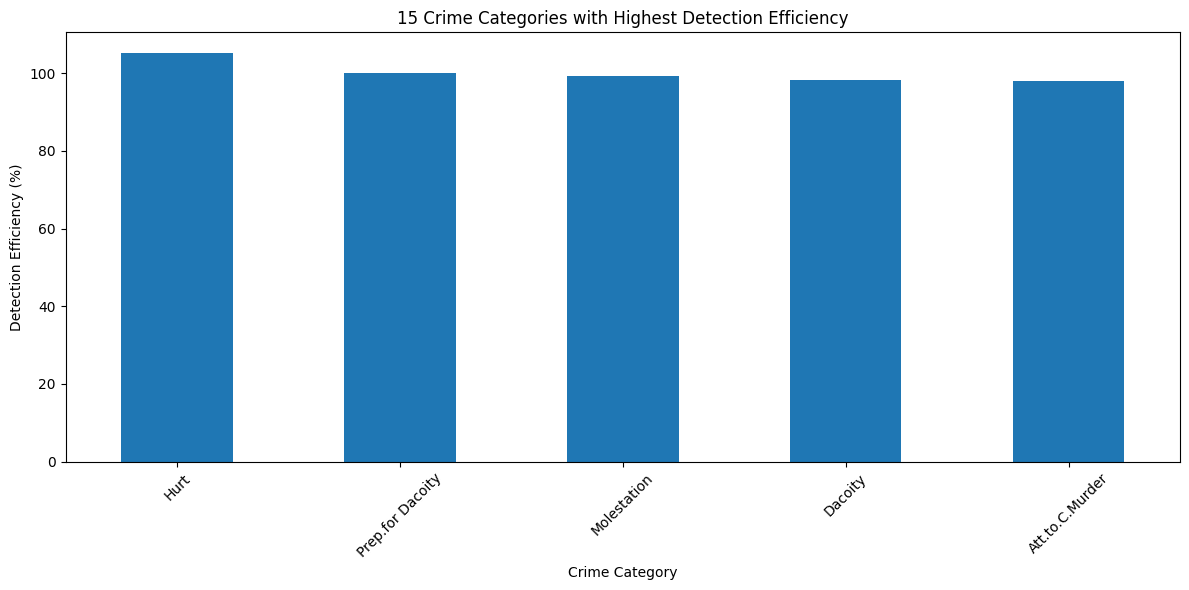

In [27]:
best = metrics.sort_values(
    "detection_efficiency",
    ascending=False
).head(5)

print(
    best[
        [
            "detection_efficiency",
            "backlog_change",
            "backlog_status"
        ]
    ]
)

plt.figure(figsize=(12,6))

best["detection_efficiency"].plot(
    kind="bar"
)

plt.title("15 Crime Categories with Highest Detection Efficiency")
plt.ylabel("Detection Efficiency (%)")
plt.xlabel("Crime Category")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

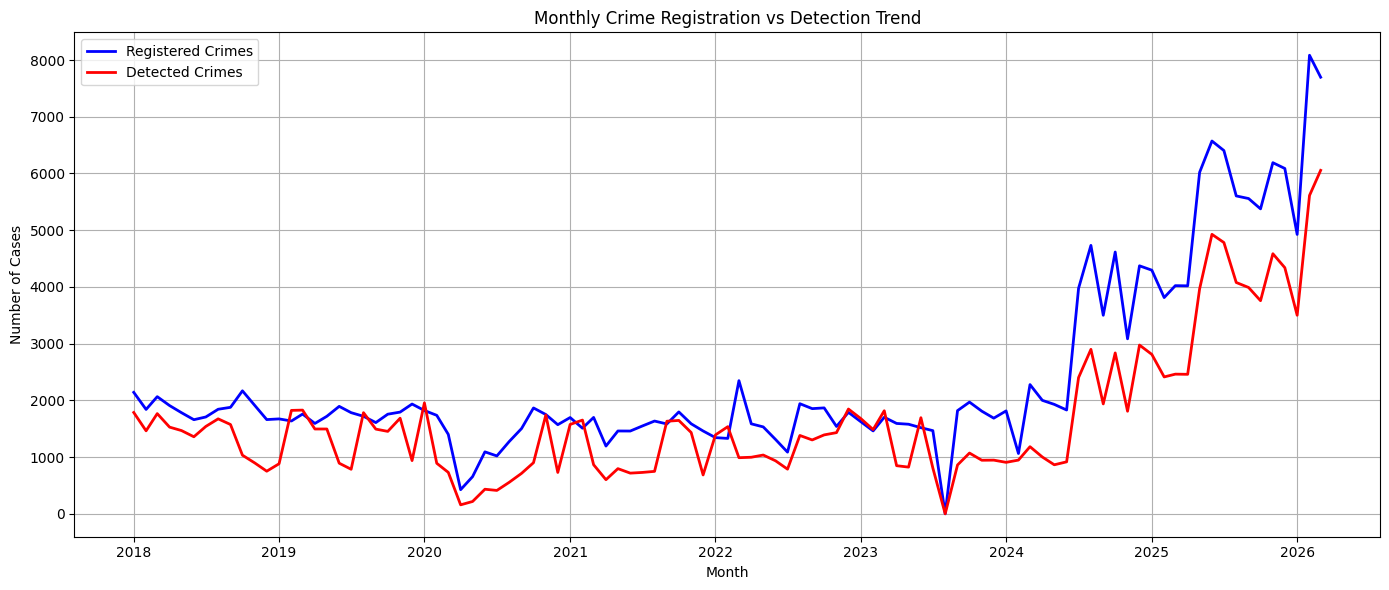

In [30]:
df["month"] = pd.to_datetime(df["month"])
plt.figure(figsize=(14,6))

monthly = (
    df.groupby("month")["current_month_reg"]
      .sum()
)

monthly_det = (
    df.groupby("month")["current_month_det"]
      .sum()
)

plt.plot(
    monthly.index,
    monthly.values,
    color="blue",
    label="Registered Crimes",
    linewidth=2
)

plt.plot(
    monthly_det.index,
    monthly_det.values,
    color="red",
    label="Detected Crimes",
    linewidth=2
)

plt.title("Monthly Crime Registration vs Detection Trend")
plt.xlabel("Month")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

                 growth_pct
crime_category             
Snatching         52.256944
Other I.P.C.      27.433721
Rape               7.323956
Extortion          7.138819
Att.to.C.Murder    5.128373
Molestation        4.759565
Thefts.            1.448763
Riots.             0.211788
Murder             0.178131
Hurt              -2.540330


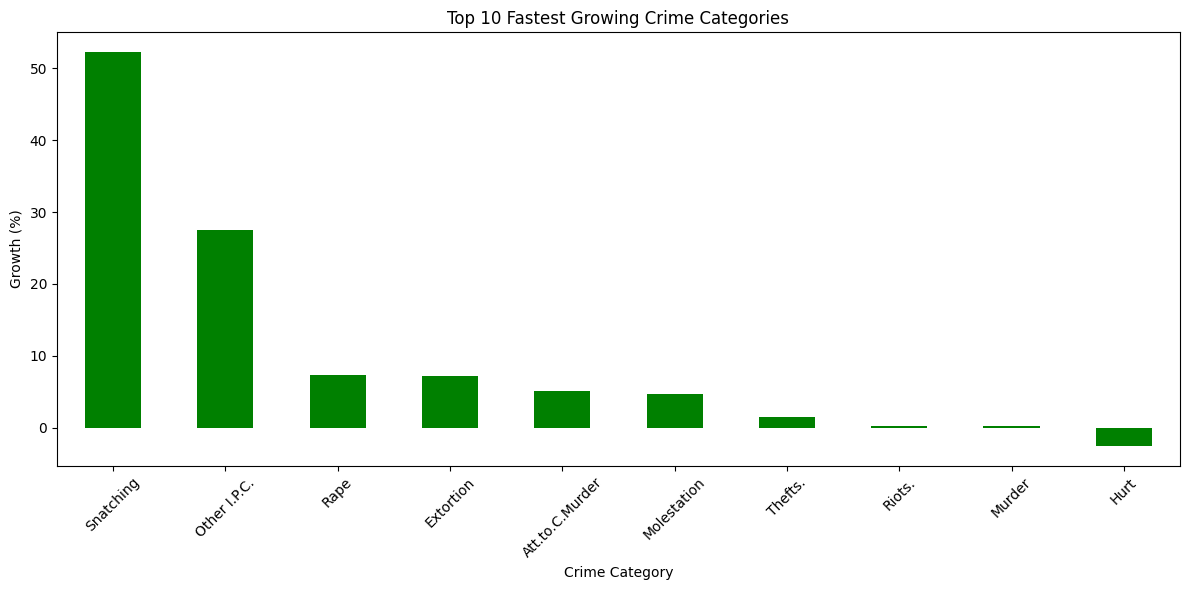

In [34]:
growth = (
    df.groupby("crime_category")
      .agg({
          "current_year_reg":"sum",
          "previous_year_reg":"sum"
      })
)

growth["growth_pct"] = (
    (
        growth["current_year_reg"]
        -
        growth["previous_year_reg"]
    )
    /
    growth["previous_year_reg"]
) * 100

growth = growth.sort_values(
    "growth_pct",
    ascending=False
)

print(growth[["growth_pct"]].head(10))

plt.figure(figsize=(12,6))

growth["growth_pct"]\
.head(10)\
.plot(
    kind="bar",
    color="green"
)

plt.title("Top 10 Fastest Growing Crime Categories")
plt.ylabel("Growth (%)")
plt.xlabel("Crime Category")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

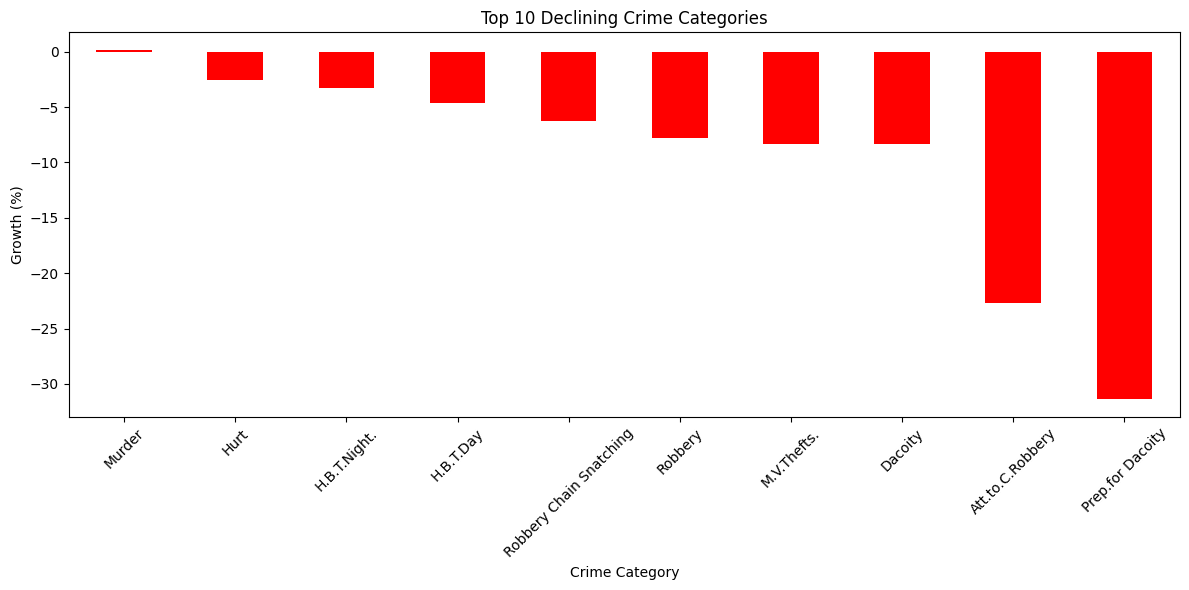

In [35]:
plt.figure(figsize=(12,6))

growth["growth_pct"]\
.tail(10)\
.plot(
    kind="bar",
    color="red"
)

plt.title("Top 10 Declining Crime Categories")
plt.ylabel("Growth (%)")
plt.xlabel("Crime Category")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

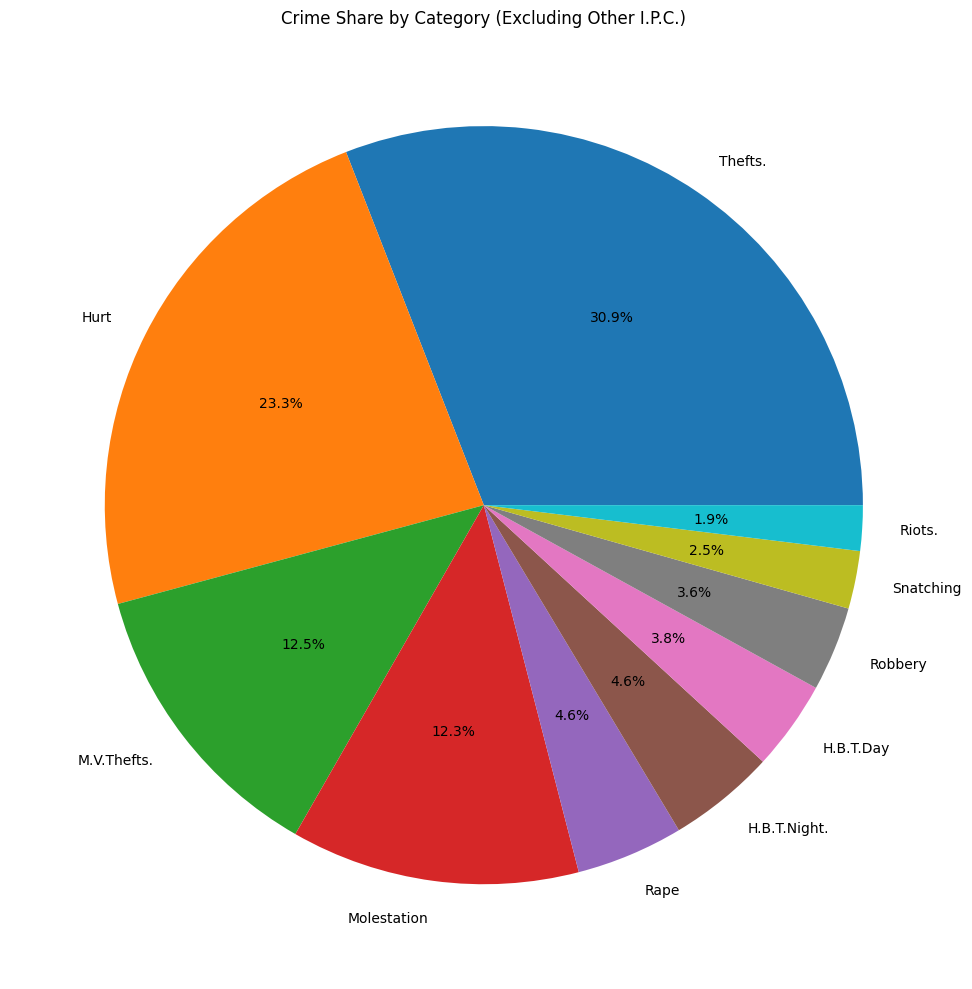

In [36]:
share = (
    crime_totals.drop("Other I.P.C.", errors="ignore")
    / crime_totals.drop("Other I.P.C.", errors="ignore").sum()
    * 100
).sort_values(ascending=False)

plt.figure(figsize=(10,10))

share.head(10).plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Crime Share by Category (Excluding Other I.P.C.)")
plt.ylabel("")

plt.tight_layout()
plt.show()

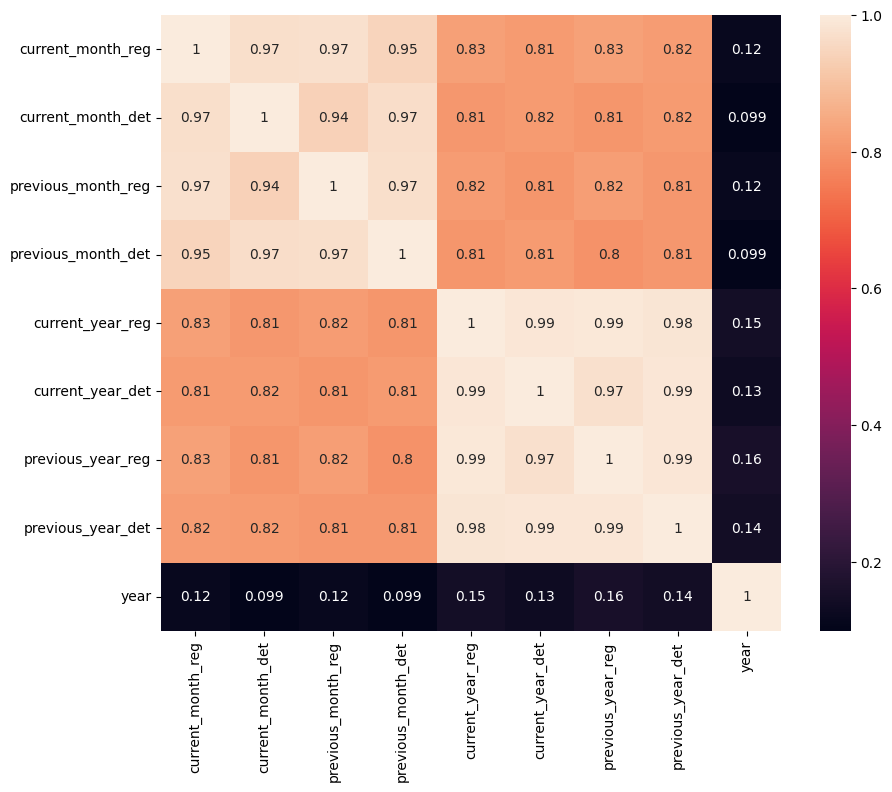

In [38]:
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.show()

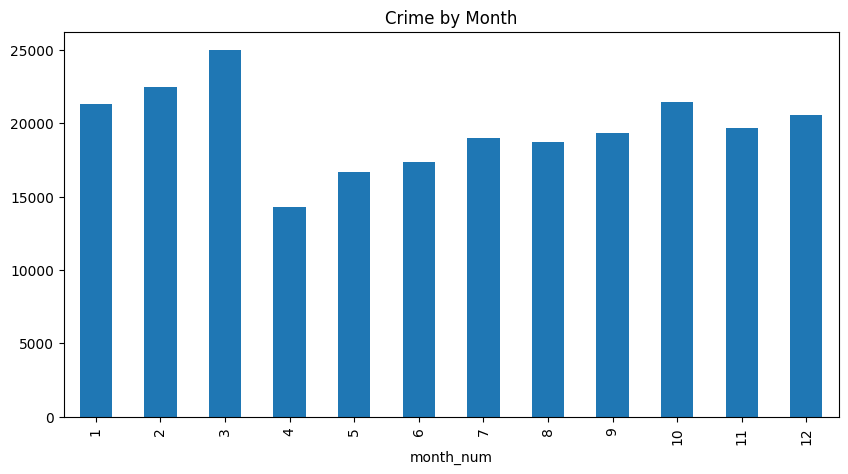

In [41]:
df["month_num"] = pd.to_datetime(df["month"]).dt.month

seasonality = (
    df.groupby("month_num")["current_month_reg"]
      .sum()
)

seasonality.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Crime by Month")
plt.show()

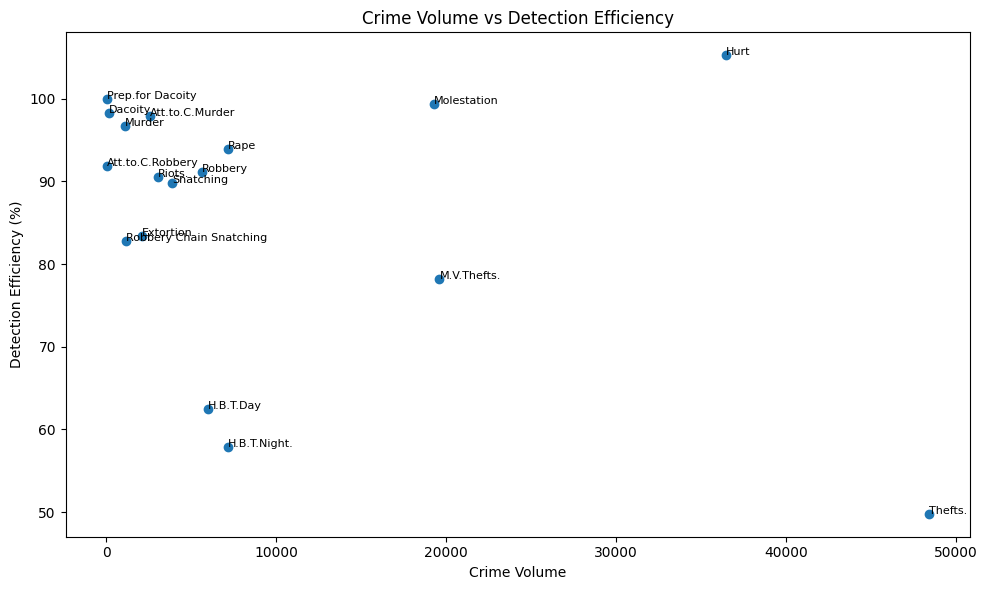

In [44]:
volume = (
    df.groupby("crime_category")["current_month_reg"]
      .sum()
      .drop("Other I.P.C.", errors="ignore")
)

analysis = pd.DataFrame({
    "volume": volume,
    "efficiency": metrics["detection_efficiency"]
})

analysis = analysis.drop("Other I.P.C.", errors="ignore")

plt.figure(figsize=(10,6))

plt.scatter(
    analysis["volume"],
    analysis["efficiency"]
)

for crime in analysis.index:
    plt.annotate(
        crime,
        (
            analysis.loc[crime, "volume"],
            analysis.loc[crime, "efficiency"]
        ),
        fontsize=8
    )

plt.xlabel("Crime Volume")
plt.ylabel("Detection Efficiency (%)")
plt.title("Crime Volume vs Detection Efficiency")

plt.tight_layout()
plt.show()

In [45]:
metrics["risk_score"] = (
    metrics["backlog_change"] *
    (100 - metrics["detection_efficiency"])
)

risk = metrics.sort_values(
    "risk_score",
    ascending=False
)

print(
    risk[
        ["risk_score"]
    ].head(10)
)

                         risk_score
crime_category                     
Thefts.                   573183.60
H.B.T.Night.              137205.90
Other I.P.C.              111725.60
H.B.T.Day                  73936.86
M.V.Thefts.                46348.33
Extortion                   5853.76
Robbery                     4420.00
Hurt                        3860.84
Robbery Chain Snatching     3384.46
Rape                        2908.80
